# 2024 Wide Receiver Model Validation

## tl;dr

Four time-aware approaches were trained or defined using 2021–2023 and
evaluated on 1,376 eligible WR appearances from 2024.

- Adding air-yard share to target share changed MAE from `4.93936` to `4.93935`
  PPR points—an immaterial improvement.
- The combined model using target share, air-yard share, and recent PPR produced
  the best MAE (`4.853`) and RMSE (`6.645`).
- The direct five-game PPR baseline remained competitive (`4.933` MAE).

The secondary hypothesis received only negligible support: air-yard share
technically improved the opportunity-only model, but not by a practically
meaningful amount.

## Context & Methods

### Question

Does five-game air-yard share improve predictions beyond five-game target share?

### Key Assumptions

- Training seasons: 2021–2023
- Validation season: 2024
- Final test season: 2025, not loaded by this notebook
- Every row has five prior same-season WR appearances
- Zero-target appearances remain in rolling histories
- Ordinary least squares is used as an interpretable first model
- Mean absolute error (MAE) is the primary selection metric

MAE represents the average absolute difference between predicted and actual PPR
points. Lower is better.

## Data

### 1. Load the locked development and validation populations

In [1]:
import os
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", str(Path.cwd() / "work" / "matplotlib"))

import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd()
DATA_PATH = PROJECT_ROOT / "data" / "processed" / "wr_weekly_features.csv"
FIGURE_PATH = PROJECT_ROOT / "reports" / "figures" / "validation_model_mae.svg"

all_weeks = pd.read_csv(DATA_PATH, low_memory=False)
eligible_weeks = all_weeks.loc[
    all_weeks["season"].between(2021, 2024)
    & all_weeks["rolling_5_target_share"].notna()
].copy()

training = eligible_weeks.loc[eligible_weeks["season"].between(2021, 2023)].copy()
validation = eligible_weeks.loc[eligible_weeks["season"].eq(2024)].copy()

print(f"Training appearances: {len(training):,}")
print(f"Validation appearances: {len(validation):,}")
assert training["season"].max() == 2023
assert validation["season"].nunique() == 1
assert validation["season"].iloc[0] == 2024
assert not (eligible_weeks["season"] == 2025).any()

Training appearances: 4,199
Validation appearances: 1,376


## Results

### 2. Fit interpretable linear models

In [2]:
def fit_linear_model(feature_columns):
    training_matrix = np.column_stack(
        [np.ones(len(training)), training[feature_columns].to_numpy(float)]
    )
    coefficients = np.linalg.lstsq(
        training_matrix,
        training["fantasy_points_ppr"].to_numpy(float),
        rcond=None,
    )[0]
    validation_matrix = np.column_stack(
        [np.ones(len(validation)), validation[feature_columns].to_numpy(float)]
    )
    return validation_matrix @ coefficients


predictions = {
    "Five-game PPR baseline": validation["rolling_5_fantasy_points_ppr"].to_numpy(float),
    "Target share only": fit_linear_model(["rolling_5_target_share"]),
    "Target + air-yard share": fit_linear_model(
        ["rolling_5_target_share", "rolling_5_air_yards_share"]
    ),
    "Target + air-yard + recent PPR": fit_linear_model(
        [
            "rolling_5_target_share",
            "rolling_5_air_yards_share",
            "rolling_5_fantasy_points_ppr",
        ]
    ),
}

### 3. Compare validation errors

In [3]:
actual = validation["fantasy_points_ppr"].to_numpy(float)
total_squared_error = np.sum((actual - actual.mean()) ** 2)
metric_rows = []

for model_name, prediction in predictions.items():
    residual = actual - prediction
    metric_rows.append(
        {
            "model": model_name,
            "MAE": np.mean(np.abs(residual)),
            "RMSE": np.sqrt(np.mean(residual**2)),
            "R_squared": 1 - (np.sum(residual**2) / total_squared_error),
        }
    )

validation_metrics = pd.DataFrame(metric_rows).sort_values("MAE").reset_index(drop=True)
print(validation_metrics.round({"MAE": 3, "RMSE": 3, "R_squared": 3}).to_string(index=False))

                         model   MAE  RMSE  R_squared
Target + air-yard + recent PPR 4.853 6.645      0.337
        Five-game PPR baseline 4.933 6.853      0.295
       Target + air-yard share 4.939 6.713      0.323
             Target share only 4.939 6.714      0.323


### 4. Visualize mean absolute error

C:\Users\Brecken\Documents\Codex\2026-07-22\hi\outputs\fantasy-football-wr-analytics\reports\figures\validation_model_mae.svg


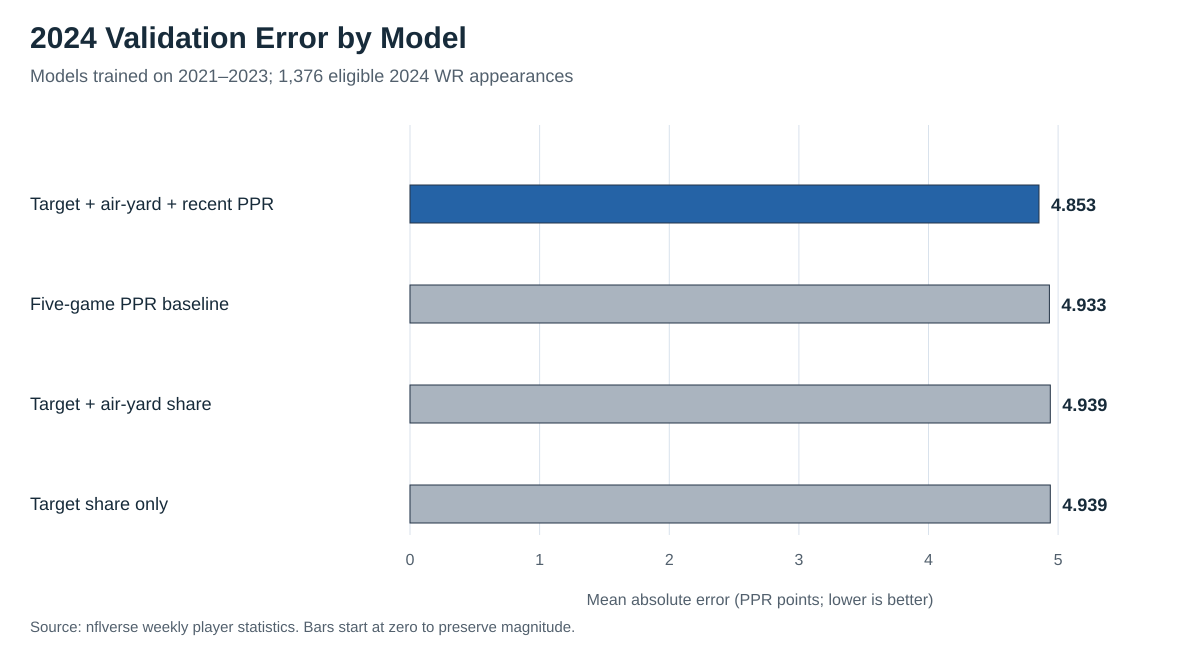

In [4]:
chart_data = validation_metrics.sort_values("MAE", ascending=True).reset_index(drop=True)
width, height = 1200, 650
label_x, bar_x, max_bar_width = 30, 410, 700
scale_max = 5.4
row_y = [185, 285, 385, 485]

svg_parts = [
    f'<svg xmlns="http://www.w3.org/2000/svg" width="{width}" height="{height}" viewBox="0 0 {width} {height}">',
    '<rect width="100%" height="100%" fill="#ffffff"/>',
    '<style>text{font-family:Arial,sans-serif;fill:#172B3A}.title{font-size:30px;font-weight:700}.subtitle{font-size:18px;fill:#52606D}.label{font-size:18px}.value{font-size:18px;font-weight:700}.note{font-size:15px;fill:#52606D}.axis{font-size:16px;fill:#52606D}</style>',
    '<text x="30" y="48" class="title">2024 Validation Error by Model</text>',
    f'<text x="30" y="82" class="subtitle">Models trained on 2021–2023; {len(validation):,} eligible 2024 WR appearances</text>',
]

for _, tick_value in enumerate(range(0, 6)):
    tick_x = bar_x + (tick_value / scale_max) * max_bar_width
    svg_parts.append(f'<line x1="{tick_x:.1f}" y1="125" x2="{tick_x:.1f}" y2="535" stroke="#D9E2EC" stroke-width="1"/>')
    svg_parts.append(f'<text x="{tick_x:.1f}" y="565" text-anchor="middle" class="axis">{tick_value}</text>')

for row_index, row in chart_data.iterrows():
    y = row_y[row_index]
    bar_width = (row["MAE"] / scale_max) * max_bar_width
    color = "#2563A6" if row["model"] == "Target + air-yard + recent PPR" else "#AAB4BF"
    svg_parts.extend(
        [
            f'<text x="{label_x}" y="{y + 25}" class="label">{row["model"]}</text>',
            f'<rect x="{bar_x}" y="{y}" width="{bar_width:.1f}" height="38" fill="{color}" stroke="#243447" stroke-width="1"/>',
            f'<text x="{bar_x + bar_width + 12:.1f}" y="{y + 26}" class="value">{row["MAE"]:.3f}</text>',
        ]
    )

svg_parts.extend(
    [
        '<text x="760" y="605" text-anchor="middle" class="axis">Mean absolute error (PPR points; lower is better)</text>',
        '<text x="30" y="632" class="note">Source: nflverse weekly player statistics. Bars start at zero to preserve magnitude.</text>',
        "</svg>",
    ]
)

FIGURE_PATH.parent.mkdir(parents=True, exist_ok=True)
FIGURE_PATH.write_text("\n".join(svg_parts), encoding="utf-8")
print(FIGURE_PATH)

## Takeaways

- The target-share-only model and target-plus-air-yard model produced
  essentially identical MAE.
- Air-yard share did not provide a practically meaningful standalone gain once
  target share was already present.
- Combining opportunity measures with recent PPR produced the best validation
  result, suggesting the feature families may be complementary.
- The best model improved MAE by about `0.080` PPR points, or roughly `1.6%`,
  versus the direct five-game PPR baseline.

This improvement is modest. Before opening 2025, we should decide whether the
combined model is sufficiently interpretable and useful to advance unchanged.